# Изучение  Segmentation Models PyTorch  

__Цель__ Изучение библиотеки моделей `Segmentation Models PyTorch` - одной из наиболее полезных бибилотек моделей семантической сегментации.

Задачи:
1. Установить [`Segmentation Models PyTorch`](https://segmentation-modelspytorch.readthedocs.io/en/latest/).
2. Изучить примеры работы и тектс ниже
3. Выполнить задания для самоконтроля
4. Выполнить учебное задание

## Импорт torch

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import ssl
ssl._create_default_https_context = ssl._create_stdlib_context

In [3]:
сolab_requirements = ["pip install albumentations","pip install segmentation_models_pytorch"]

import sys, subprocess

def run_subprocess_command(cmd):
    process = subprocess.Popen(cmd.split(), stdout=subprocess.PIPE)
    for line in process.stdout:
        print(line.decode().strip())

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    for i in сolab_requirements:
        run_subprocess_command(i)

In [4]:
import random
import numpy as np
import matplotlib.pyplot as plt

import os
import copy
import time

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data

import torchvision
from torchvision import transforms, datasets
import torchvision.transforms as T

from torchinfo import summary

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

from tqdm.notebook import tqdm, trange

import pandas as pd

import albumentations 
from albumentations.pytorch import ToTensorV2
import albumentations as A
from albumentations.pytorch import ToTensorV2

from torch.utils.data import Dataset, DataLoader

Настроим работу с `PyTorch`. Выбирем формат работы и устройство для работы.

In [5]:
def torch_stats(): 
    torch_version = ".".join(torch.__version__.split(".")[:2])
    print('torch version:',torch_version)
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print('Using device:', device)
    dtype = torch.float32
    
    if device.type == 'cuda':
        cuda_version  = torch.__version__.split("+")[-1]
        print("cuda: ", cuda_version)
        
        torch.set_default_tensor_type(torch.cuda.FloatTensor)
        print('Cuda is available:',torch.cuda.is_available())

        n_devices = torch.cuda.device_count()
        print('number of devices: %d'%(n_devices))

        for cnt_device in range(n_devices):
            print(torch.cuda.get_device_name(cnt_device))
            print('Memory Usage:')
            print('Allocated:', round(torch.cuda.memory_allocated(cnt_device)/1024**3,1), 'GB')
            print('Cached:   ', round(torch.cuda.memory_reserved(cnt_device)/1024**3,1), 'GB')


    torch.set_default_dtype(dtype) # float32
    print('default data type:',dtype)
    
    num_workers=os.cpu_count()
    print ('available number of workers:',num_workers)
    
    return device, dtype, num_workers
#-------------------------------
def torch_seed(seed = 42, deterministic = True):
    random.seed(seed) # random and transforms
    np.random.seed(seed) #numpy
    torch.manual_seed(seed) #cpu
    torch.cuda.manual_seed(seed) #gpu
    torch.backends.cudnn.deterministic=deterministic #cudnn    
#-------------------------------    
def clean_memory():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    to_remove = set()
    for k, v in globals().items():
        if isinstance(v, (torch.nn.Module)):
            to_remove.add(k)
    for k in to_remove:
        del globals()[k]
    gc.collect()    


In [7]:
torch.cuda.is_available()

True

## Набор данных для сегментации

Посмотрим содержания созданного архива. Архив содержит директорию изображениями `images` и директорию с аннотацией `images/trimaps`. Всего в архиве должно быть 7393 изображения. 

In [8]:
root_directory = os.path.join(os.getcwd(),'data/segmentation/train/')
content = os.listdir(root_directory)
print(content)
print('n images = ',len(os.listdir(os.path.join(root_directory, 'images'))))
# print('n anno = ',len(os.listdir(os.path.join(dataset_directory, content[0], "trimaps" ))))

['masks', 'images']
n images =  5918


Теперь пробуем разбить изображения на тренировочную, валидационную и тестовую выборки. 

В тренировочную выборку поместим 6000 случайно выбранных изображений.
В тестовую выборку поместим 100 случайно выбранных изображений.

In [9]:
N_TRAIN = 6000
N_TEST  = 100
STEP    = 1

images_directory = os.path.join(root_directory, "images")
masks_directory  = os.path.join(root_directory, "masks")

images_filenames = os.listdir(images_directory)
print(len(images_filenames))

images_filenames = [i for i in images_filenames 
                        if os.path.splitext(i)[-1]                     
                            in ('.png', '.jpg', '.jpeg', '.tiff', '.bmp', '.gif')]

# os.path.splitext('/path/to/somefile.ext')

random.shuffle(images_filenames)

train_images_filenames = images_filenames[:N_TRAIN:STEP]
# val_images_filenames   = images_filenames[N_TRAIN:-N_TEST:STEP]
test_images_filenames  = images_filenames[-N_TEST::STEP]
val_images_filenames = test_images_filenames 
print(len(train_images_filenames), len(val_images_filenames), len(test_images_filenames))

5918
5918 100 100


In [10]:
from torch.utils.data import Dataset

class PetsDataset(Dataset):
    def __init__(self, images_filenames, images_directory, masks_directory, transforms=None):
        
        self.images_filenames = images_filenames
        self.images_directory = images_directory
        self.masks_directory  = masks_directory
        
        self.transforms = transforms

    def __len__(self):
        return len(self.images_filenames)
   
    def preprocess_mask(self, mask):
        mask = np.asarray(mask).astype(np.float32)
        mask[mask == 2.0] = 0.0
        mask[(mask == 1.0) | (mask == 3.0)] = 1.0
        return mask
    
    def __getitem__(self, idx):

        image_filename = self.images_filenames[idx]
        
        path_ = os.path.join(self.images_directory, image_filename)    
        image = np.asarray(Image.open(path_).convert("RGB"))
        
        path_ = os.path.join(self.masks_directory, image_filename.replace(".jpg", ".png"))    
        mask  = Image.open(path_)
        mask  = self.preprocess_mask(mask)

        if self.transforms is not None:
            transformed = self.transforms(image=image, mask=mask)
            image = transformed["image"]
            mask  = transformed["mask"]

        return image, mask

In [12]:
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

train_transform = A.Compose([A.Resize(128, 128),   
                             # A.RandomCrop(256,256),
                             A.ShiftScaleRotate(0.2,0.2, 10),
                             A.Normalize(mean, std),
                             ToTensorV2(),])

test_transform = A.Compose([A.Resize(256, 256), 
                            A.Normalize(mean, std), 
                            ToTensorV2()])

train_dataset = PetsDataset(train_images_filenames, images_directory, masks_directory, transforms=train_transform,)

val_dataset   = PetsDataset(val_images_filenames,   images_directory, masks_directory, transforms=test_transform,)

test_dataset  = PetsDataset(test_images_filenames,  images_directory, masks_directory, transforms=test_transform,)
val_dataset = test_dataset
print(f"Train size: {len(train_dataset)}")
print(f"Valid size: {len(val_dataset)}")
print(f"Test size: {len(test_dataset)}")

Train size: 5918
Valid size: 100
Test size: 100


Теперь попробуем визуализировать некоторые изображения и их маски. Для этого создадим функцию visualize_data

In [13]:
from PIL import Image
def visualize_dataset(dataset, samples=5, predicted_masks = None, mean = mean, std = std):
    dataset = copy.deepcopy(dataset)
    cols = 3 if predicted_masks else 2
    
    figure, ax = plt.subplots(nrows=samples, ncols=cols, figsize=(10, 12))
    
    for i in range(samples):
        image, mask = dataset[i]
        
        image = image.data.cpu().numpy().transpose((1,2,0))
        image = np.clip(image*std + mean,0,1)
        
        mask = np.clip(mask,0,1)
               

        ax[i, 0].imshow(image)
        ax[i, 0].set_title("Image"); ax[i, 0].set_axis_off()
        ax[i, 1].imshow(mask.data.cpu().numpy(), interpolation="nearest")
        ax[i, 1].set_title("Ground Truth");  ax[i, 1].set_axis_off()     
        if predicted_masks:
            predicted_mask = predicted_masks[i]
            ax[i, 2].imshow(predicted_mask, interpolation="nearest")
            ax[i, 2].set_title("Predicted Mask"); ax[i, 2].set_axis_off()
    
    plt.tight_layout()
    plt.show()

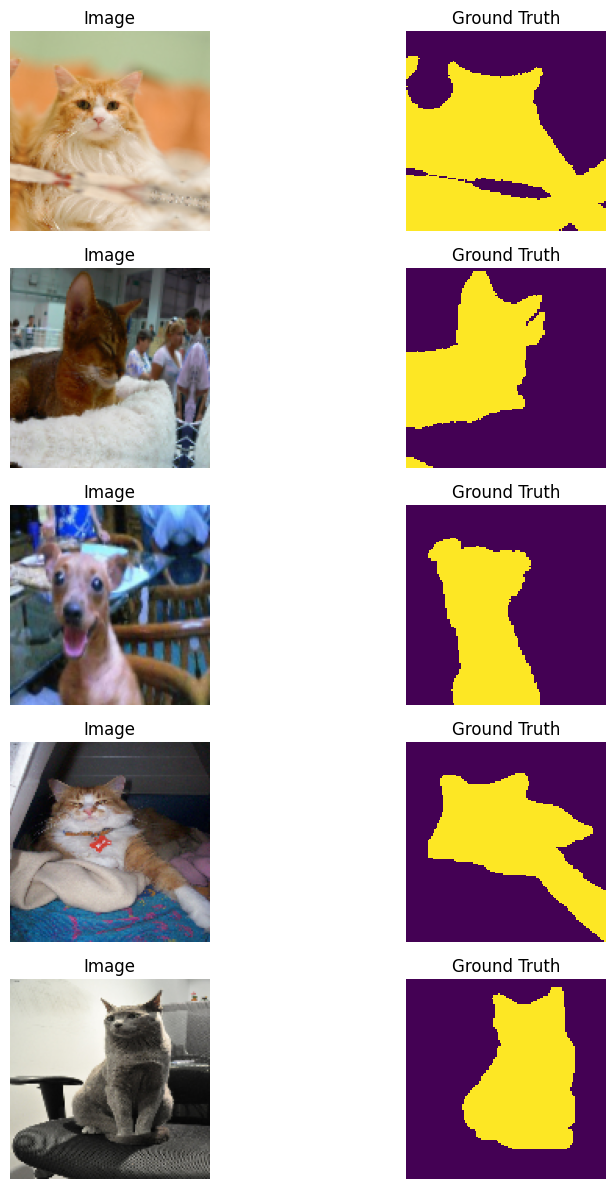

In [14]:
visualize_dataset(train_dataset, samples=5)

In [15]:
BATCH = 16

if torch.cuda.is_available():
    kwarg = {'generator':torch.Generator(device='cuda'), 'pin_memory':True}
else:
     kwarg = {'num_workers':0, 'generator':torch.Generator(device=device)}

train_loader = DataLoader(
                train_dataset,
                batch_size=BATCH,
                shuffle=True,
                **kwarg)

val_loader = DataLoader(
                val_dataset,
                batch_size=BATCH,
                shuffle=False,
                **kwarg)

test_loader = DataLoader(
                test_dataset,
                batch_size=BATCH,
                shuffle=False,
                **kwarg)

## Библиотека `segmentation_models_pytorch`

 Одной из наиболее популярных библиотек для решения задач сегментации при помощи сверточных нейронных сетей является  [`segmentation_models_pytorch`, `SMP`](https://github.com/qubvel/segmentation_models.pytorch). Библиотек `SMP` предоставляет широкий перечень архитектур сегментации и кодировщиков для них. Такими кодировщиками могут быть как встроенные модели, например `resnet` и `efficientnet` так и набор кодировщиков `timm`. Также `SMP`предоставляет ряд вспомогательных функций. Более подробную информацию можно найти в  [официальной документации](hhttps://smp.readthedocs.io/en/latest/) и [уроках](https://github.com/qubvel/segmentation_models.pytorch/tree/master/examples).  Ниже приведен пример использования библиотек

In [16]:

import segmentation_models_pytorch as smp
# We will use Feature Pyramid Network with pre-trained efficientnet backbone
# model = smp.PSPNet(encoder_name="mit_b2", encoder_weights="imagenet", classes=1,)
model = smp.UnetPlusPlus(encoder_name="efficientnet-b1", encoder_weights="imagenet", classes=1,)


In [17]:
summary(model, (1,3,224,224))

Layer (type:depth-idx)                                  Output Shape              Param #
UnetPlusPlus                                            [1, 1, 224, 224]          --
├─EfficientNetEncoder: 1-1                              [1, 3, 224, 224]          412,160
│    └─Conv2dStaticSamePadding: 2-1                     [1, 32, 112, 112]         864
│    │    └─ZeroPad2d: 3-1                              [1, 3, 225, 225]          --
│    └─BatchNorm2d: 2-2                                 [1, 32, 112, 112]         64
│    └─MemoryEfficientSwish: 2-3                        [1, 32, 112, 112]         --
│    └─ModuleList: 2-4                                  --                        --
│    │    └─MBConvBlock: 3-2                            [1, 16, 112, 112]         1,448
│    │    └─MBConvBlock: 3-3                            [1, 16, 112, 112]         612
│    │    └─MBConvBlock: 3-4                            [1, 24, 56, 56]           6,004
│    │    └─MBConvBlock: 3-5                   

In [18]:
x=torch.rand(*(1,3,128,128))
y = model(x)
y.shape

torch.Size([1, 1, 128, 128])

также, на самом деле, можно работать и с функциями потерь.

см.  [тут](https://smp.readthedocs.io/en/latest/losses.html).

In [19]:
criterion = smp.losses.DiceLoss(smp.losses.BINARY_MODE, from_logits=True)


In [20]:
def accuracy(output, target):
    output = torch.squeeze(output, dim=1)

    tp, fp, fn, tn = smp.metrics.get_stats(output, target, mode='binary', threshold=0.5)
    iou_score = smp.metrics.iou_score(tp, fp, fn, tn, reduction="macro")
    # accuracy = smp.metrics.accuracy(tp, fp, fn, tn, reduction="macro")

    return iou_score

In [21]:
model.to(device)
criterion.to(device)

DiceLoss()

In [22]:
LR = 0.001
trainable_parameters = filter(lambda p: p.requires_grad, model.parameters())
optimizer = optim.AdamW(trainable_parameters, lr=LR)

In [23]:
#-------------------    
def train(model, dataloader, optimizer, criterion, metric,  device):

    epoch_loss = 0
    epoch_acc  = 0

    model.train()

    for (x, y) in tqdm(dataloader, desc="Training", leave=False):

        x, y = x.to(device), y.to(device).long()

        optimizer.zero_grad(set_to_none = True)

        y_pred = model(x)

        loss = criterion(y_pred, y)
        acc  = metric(y_pred, y)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        epoch_acc  += acc.item()

    return epoch_loss / len(dataloader), epoch_acc / len(dataloader)
#-------------------
def evaluate(model, dataloader, criterion, metric, device):

    epoch_loss = 0
    epoch_acc  = 0

    model.eval()

    with torch.inference_mode():
        
        for (x, y) in tqdm(dataloader, desc="Evaluating", leave=False):

            x, y = x.to(device), y.to(device).long()

            y_pred = model.forward(x)

            loss = criterion(y_pred, y)
            acc  = metric( y_pred, y)

            epoch_loss += loss.item()
            epoch_acc  += acc.item()

    return epoch_loss / len(dataloader), epoch_acc / len(dataloader)

#-------------------
def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

#-------------------
def fit(model, train_loader, val_loader, optimizer, criterion, metric, epochs = 10, device='cpu', scheduler = None,  path_best = 'best_model.pt', verbose = True):
    
    best_valid_loss = float('inf')
    torch.save(model.state_dict(), path_best)
    
    for epoch in trange(epochs):

        start_time = time.monotonic()

        train_loss, train_acc = train(model, train_loader, optimizer, criterion, metric, device)
        valid_loss, valid_acc = evaluate(model, val_loader, criterion, metric, device)
        
        if scheduler != None:
            scheduler.step()
        
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            torch.save(model.state_dict(), path_best)
        
        end_time = time.monotonic()

        epoch_mins, epoch_secs = epoch_time(start_time, end_time)       
    
        if verbose == True:
            if epoch%2 == 1:    # print every 2 epochs:
                print(f'Epoch: {epoch+1:02} | Epoch Time: {epoch_mins}m {epoch_secs}s | LR {optimizer.param_groups[0]["lr"] :.4f}')
                print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%',
                f' | Val. Loss: {valid_loss:.3f} | Val. Acc: {valid_acc*100:.2f}%') 

In [24]:
device = 'cuda'

In [25]:
fit(model, train_loader, val_loader, optimizer, criterion, accuracy, epochs = 1, device=device, verbose = True)

  0%|          | 0/1 [00:00<?, ?it/s]

Training:   0%|          | 0/370 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/7 [00:00<?, ?it/s]

In [26]:
model.eval()
with torch.no_grad():
    x,y = next(iter(val_loader)) 
    x,y = x.to(device), y.to(device)
    y_pred = torch.sigmoid(model.forward(x)).detach().cpu()
y_pred.shape

torch.Size([16, 1, 256, 256])

In [27]:
y_pred[0]

tensor([[[8.1045e-01, 9.2386e-01, 9.5224e-01,  ..., 8.7324e-03,
          1.6969e-02, 9.1924e-02],
         [9.1368e-01, 9.8589e-01, 9.9339e-01,  ..., 5.8708e-04,
          1.3650e-03, 1.7451e-02],
         [9.4954e-01, 9.9423e-01, 9.9749e-01,  ..., 2.1804e-04,
          4.0638e-04, 7.0537e-03],
         ...,
         [9.6378e-01, 9.9537e-01, 9.9803e-01,  ..., 9.9828e-01,
          9.9543e-01, 9.5853e-01],
         [9.4372e-01, 9.9052e-01, 9.9565e-01,  ..., 9.9676e-01,
          9.9209e-01, 9.4879e-01],
         [8.2344e-01, 9.3976e-01, 9.6711e-01,  ..., 9.7936e-01,
          9.5692e-01, 8.7162e-01]]], device='cpu')

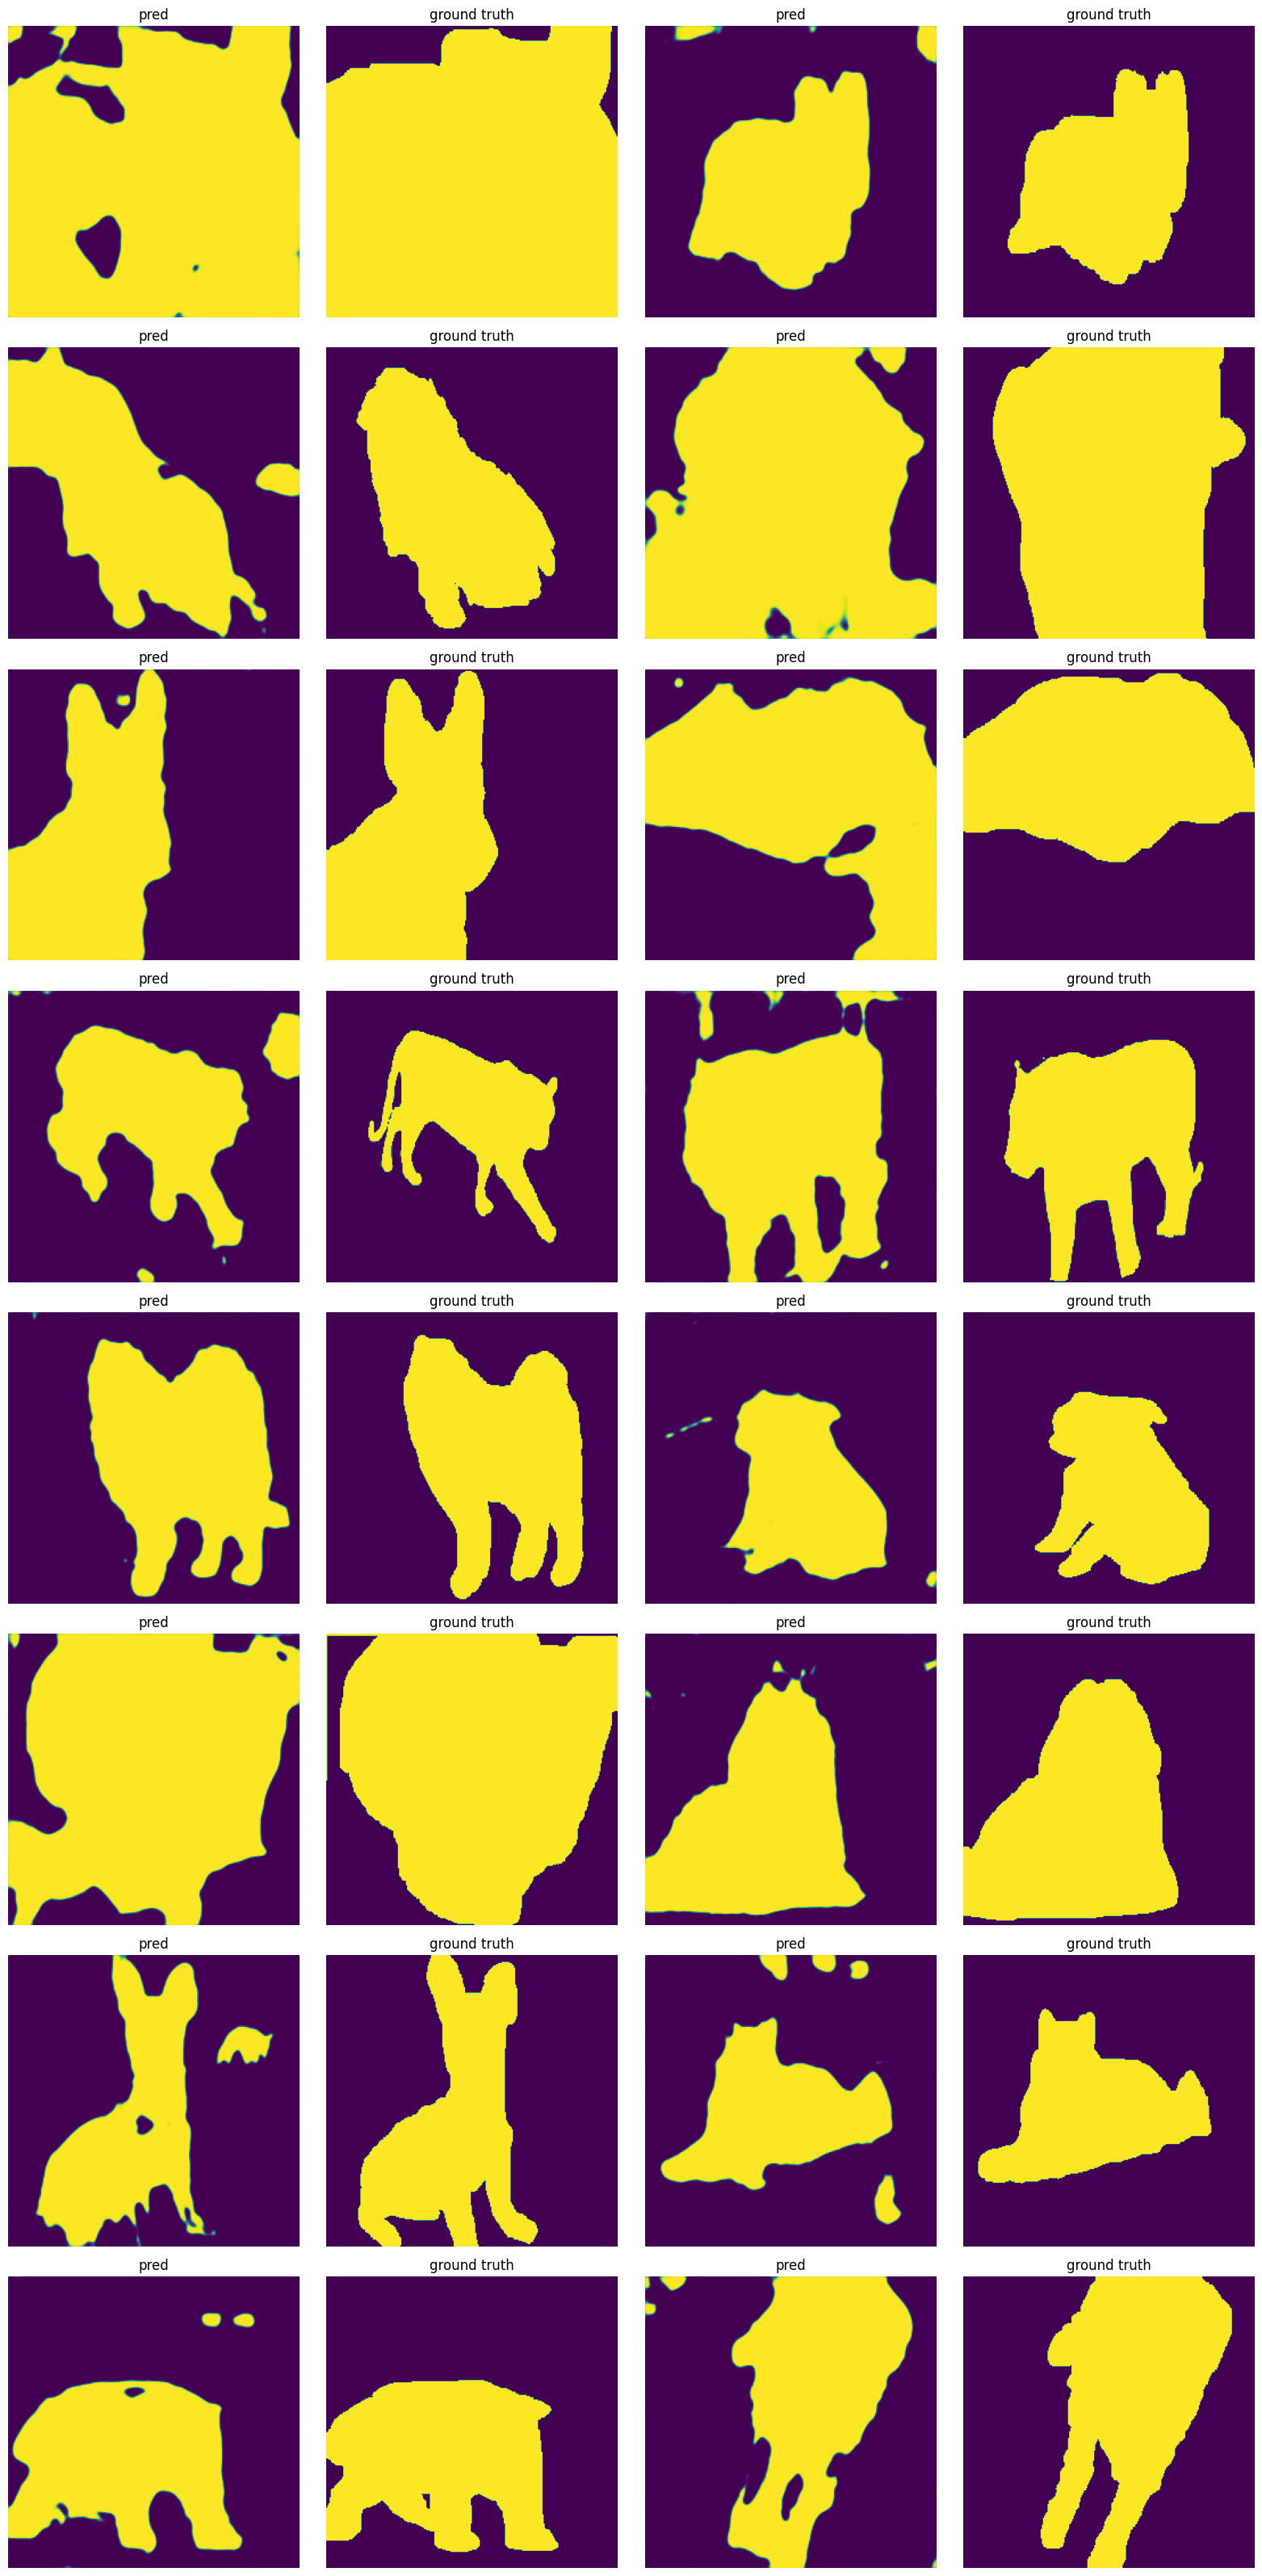

In [28]:
fig, axs = plt.subplots(8,4, figsize=(16,32))
axs_ = axs.ravel()
for i in range(0,len(axs_),2):
    mask_predicted = y_pred[i//2,0,:,:].detach().cpu().numpy()
    mask_target = y[i//2,:,:].detach().cpu().numpy()
    axs_[i].imshow(mask_predicted);  axs_[i].set_axis_off(); axs_[i].set_title('pred')
    axs_[i+1].imshow(mask_target);  axs_[i+1].set_axis_off(); axs_[i+1].set_title('ground truth')
plt.tight_layout()    
plt.show()

In [29]:
def rle_encode_tensor(mask_tensor):
    """
    Encode a PyTorch binary mask tensor into Kaggle-style RLE string.
    
    Args:
        mask_tensor: torch.Tensor of shape (H, W) or (1, H, W)
                     dtype: bool, int, or float (will be thresholded at 0.5 if float)
    
    Returns:
        str: RLE string (e.g., "1 3 10 5 ...") or empty string if no foreground
    """
    # Убираем лишние измерения
    if mask_tensor.ndim == 3:
        if mask_tensor.shape[0] == 1:
            mask_tensor = mask_tensor.squeeze(0)
        else:
            raise ValueError("Expected single-channel mask, got shape: {}".format(mask_tensor.shape))
    
    # Переводим на CPU и в numpy
    mask = mask_tensor.detach().cpu().numpy()
    
    # Бинаризуем, если нужно
    if mask.dtype == np.float32 or mask.dtype == np.float64:
        mask = mask > 0.5
    else:
        mask = mask.astype(bool)
    
    # Проверка на пустую маску
    if mask.sum() == 0:
        return ""
    
    # RLE в column-major порядке (Kaggle стандарт)
    pixels = mask.T.flatten()  # <-- ВАЖНО: .T для column-major
    pixels = np.concatenate([[0], pixels, [0]])  # паддинг
    runs = np.where(pixels[1:] != pixels[:-1])[0] + 1
    runs[1::2] -= runs[::2]
    
    return ' '.join(str(x) for x in runs)


def rle_decode(rle_string: str, shape: tuple) -> np.ndarray:
    """
    Decode a Kaggle-style RLE string into a binary mask.

    Args:
        rle_string (str): RLE string like "10 5 20 8" (start1 len1 start2 len2 ...)
        shape (tuple): (height, width) of the output mask

    Returns:
        np.ndarray: Binary mask of shape (height, width), dtype=np.uint8
    """
    if not rle_string or rle_string == "-1" or rle_string.strip() == "":
        return np.zeros(shape, dtype=np.uint8)

    rle = np.array(rle_string.split(), dtype=int)
    starts = rle[0::2] - 1  # Convert from 1-indexed to 0-indexed
    lengths = rle[1::2]

    flat_mask = np.zeros(shape[0] * shape[1], dtype=np.uint8)

    for start, length in zip(starts, lengths):
        flat_mask[start : start + length] = 1

    mask = flat_mask.reshape(shape)
    return mask

def inference(model, img):
    tensor_img = test_transform(image=img)['image']
    tensor_int = tensor_img.unsqueeze(0).to(device)
    tensor_mask = F.sigmoid(model(tensor_int))
    y_mask = tensor_mask[0].detach().cpu().numpy()[0]
    y_mask[y_mask>0.5] = 1.
    y_mask[y_mask<=0.5] = 0.
    return y_mask

Формирование предсказаний. rle кодирование бинарной маски сегментации

In [45]:
path2image = Path("./data/segmentation/test/images/")
# model.eval()
ious = []
all_masks = []
for f in path2image.glob("*"):
    img = np.asarray(Image.open(f).convert("RGB"))
    y_pred = inference(model, img)
    
    res_pred = np.zeros_like(img[:,:,0])
    res_pred[:200,100:200] = 1
    s = rle_encode_tensor(torch.tensor(res_pred))
    
    all_masks.append({"FILE_NAME":f.name,
          "TARGET":s})
    # iou = mean_iou(torch.tensor(y_pred), torch.tensor(mask),1)
    # print(iou)
    # ious.append(iou.item())

In [46]:
pd.DataFrame(all_masks).to_csv("submission.csv", index = False)

## Задания для самоконтроля

__1.__ Предлагаем оценить возможности улучшения точности при использовании различных функций активации из пакета [`SMP`](https://smp.readthedocs.io/en/latest/losses.html)

__2.__ Предлагается сравнить точность рассмотренной архитектуры `PSPNet` c `DeepLabV3+` and `UNet` для рассмотренонго кодировщика признаков  `mobilenetv3_small_075`. Отметим, что для `DeepLabV3+` кодировщик признаков должен поддерживать операцию `dialed convolution`.

# Учебное задание

__Цель__ освоение базовых навыков работы с `SMP`

__Задача__ Найти среди кодировщиков `SMP` подходящие кодировщики для `DeepLabV3` и `DeepLabV3+`.


Задание:
1. В документации `SMP` найти списки кодировщиков призрнаков.
2. Выбрать подходящие варианты для `DeepLabV3` и `DeepLabV3+` 
3. Протестировать модели, например при помощи утилиты `create_model`.
4. Записать для успешных ахритектур csv или excel файл в формате: название модели, размер модели, число параметров, ссылка.  
| назавние  | размер | параметры | ссылка |
|-----------|--------|------------|-------|
| mobilevit | small   | 5,578,632 |timm-mobilenetv3_small_075 |
4. Сохранить файл.

In [170]:
model = smp.create_model(
    arch="deeplabv3plus",                      
    encoder_name="timm-mobilenetv3_small_075",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
)